In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
import shap

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
df = pd.read_csv("data.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [17]:
target_col = df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

print("Target column:", target_col)

Target column: Purpose


In [18]:
MIN_SAMPLES = 50   # tune if needed

class_counts = y.value_counts()
rare_classes = class_counts[class_counts < MIN_SAMPLES].index

y_merged = y.apply(
    lambda x: "Other" if x in rare_classes else x
)

print("Classes before:", y.nunique())
print("Classes after :", y_merged.nunique())

Classes before: 8
Classes after : 6


In [19]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_merged)

print("Encoded classes:", label_encoder.classes_)

Encoded classes: ['Other' 'business' 'car' 'education' 'furniture/equipment' 'radio/TV']


In [20]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Feature matrix shape:", X_encoded.shape)

Feature matrix shape: (1000, 13)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "min_child_weight": [5, 10],
    "gamma": [0.5, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    param_grid=xgb_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(
    X_train_scaled,
    y_train,
    sample_weight=sample_weights
)

best_xgb = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)

Fitting 3 folds for each of 128 candidates, totalling 384 fits
Best XGB params: {'colsample_bytree': 0.7, 'gamma': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 500, 'subsample': 0.7}


In [24]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf_param_grid = {
    "n_estimators": [400, 600],
    "max_depth": [8, 12],
    "min_samples_leaf": [5, 10]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

Best RF params: {'max_depth': 8, 'min_samples_leaf': 5, 'n_estimators': 400}


In [25]:
log_reg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

knn = KNeighborsClassifier(
    n_neighbors=11,
    weights="distance"
)

models = {
    "XGBoost": best_xgb,
    "Random Forest": best_rf,
    "Logistic Regression": log_reg,
    "KNN": knn
}

In [26]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Train Accuracy": round(
            accuracy_score(y_train, y_train_pred), 4
        ),
        "Test Accuracy": round(
            accuracy_score(y_test, y_test_pred), 4
        ),
        "F1-macro": round(
            f1_score(y_test, y_test_pred, average="macro"), 4
        ),
        "F1-weighted": round(
            f1_score(y_test, y_test_pred, average="weighted"), 4
        )
    })

results_df = pd.DataFrame(results).sort_values(
    by="F1-weighted",
    ascending=False
)

results_df

,Model,Train Accuracy,Test Accuracy,F1-macro,F1-weighted
0,XGBoost,0.5700,0.395,0.2155,0.3476
3,KNN,1.0000,0.340,0.1874,0.3027
2,Logistic Regression,0.2963,0.265,0.2244,0.2946
1,Random Forest,0.6275,0.270,0.2092,0.2727


In [27]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_test_pred = best_model.predict(X_test_scaled)

print("🏆 Best model:", best_model_name)
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

🏆 Best model: XGBoost
                     precision    recall  f1-score   support

              Other       0.00      0.00      0.00         9
           business       0.50      0.05      0.09        20
                car       0.43      0.63      0.51        67
          education       0.00      0.00      0.00        12
furniture/equipment       0.32      0.22      0.26        36
           radio/TV       0.37      0.50      0.43        56

           accuracy                           0.40       200
          macro avg       0.27      0.23      0.22       200
       weighted avg       0.36      0.40      0.35       200



In [28]:
y_prob = best_model.predict_proba(X_test_scaled)

classes_present = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes_present)

y_prob = y_prob[:, classes_present]

if y_test_bin.shape[1] > 1:
    roc_auc = roc_auc_score(
        y_test_bin,
        y_prob,
        multi_class="ovr",
        average="macro"
    )
    print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.6065


In [29]:
top3_preds = np.argsort(y_prob, axis=1)[:, -3:]

top3_accuracy = np.mean([
    y_test[i] in top3_preds[i]
    for i in range(len(y_test))
])

print("Top-3 Accuracy:", round(top3_accuracy, 4))

Top-3 Accuracy: 0.81


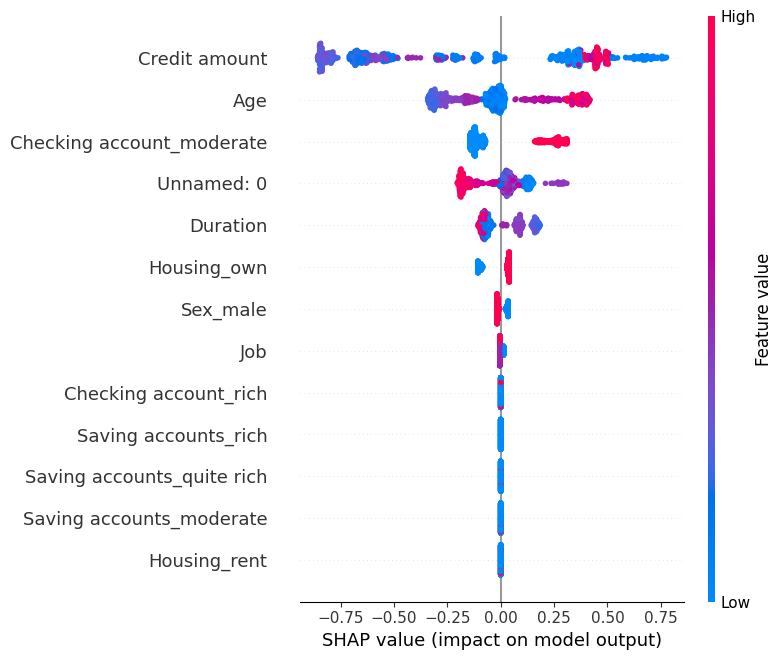

In [30]:
if best_model_name in ["XGBoost", "Random Forest"]:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_train_scaled)

    if isinstance(shap_values, list):
        shap_vals = shap_values[0]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_vals = shap_values[:, :, 0]
    else:
        shap_vals = shap_values

    shap.summary_plot(
        shap_vals,
        X_train_scaled,
        feature_names=X_encoded.columns
    )